# CS344 - HW2: Gaussian Blur en CUDA

## Descripción del problema

Aplicar un filtro de desenfoque gaussiano (Gaussian blur) a una imagen RGBA en paralelo usando CUDA.
Cada canal de color (R, G, B) se procesa de forma independiente.

## Concepto: operación Stencil

El blur gaussiano es un ejemplo clásico de **stencil**: para calcular el valor de cada píxel de salida,
se multiplica cada píxel vecino por un peso del filtro y se suman los resultados.
En paralelo, **cada thread procesa un píxel de salida independientemente**, lo que hace que
el algoritmo sea perfectamente paralelizable.

```
Pixel de salida [row, col] = suma de (filtro[i][j] * pixel_entrada[row+i, col+j])
                             para todos los vecinos dentro del filtro
```

## Pasos implementados

| Paso | Operación | Detalle |
|------|-----------|--------|
| 1 | Separar canales RGBA | Extraer R, G, B en arreglos independientes |
| 2 | Aplicar blur por canal | Kernel CUDA con patrón stencil sobre cada canal |
| 3 | Recombinar canales | Unir R, G, B procesados en imagen RGBA final |

> **Requisito:** Runtime → Change runtime type → **T4 GPU**

## Celda 1 — Configuración del entorno

Clonamos el repositorio del curso e instalamos el plugin para compilar CUDA en Colab.

In [ ]:
!git clone https://github.com/depctg/udacity-cs344-colab
!pip install git+https://github.com/depctg/nvcc4jupyter.git


Cloning into 'udacity-cs344-colab'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 144 (delta 14), reused 12 (delta 12), pack-reused 120 (from 1)
Receiving objects: 100% (144/144), 3.93 MiB | 8.54 MiB/s, done.
Resolving deltas: 100% (43/43), done.
  Cloning https://github.com/depctg/nvcc4jupyter.git to /tmp/pip-req-build-lrsicm8x
  Running command git clone --filter=blob:none --quiet https://github.com/depctg/nvcc4jupyter.git /tmp/pip-req-build-lrsicm8x
  Resolved https://github.com/depctg/nvcc4jupyter.git to commit 63b811d987446c2a3783845b7b85cda6e562b71a
  Preparing metadata (setup.py) ... done
  Created wheel for NVCCPlugin: filename=NVCCPlugin-0.0.2-py3-none-any.whl size=4315 sha256=3f8b3f68b919dbdcbe6d2dc491838e67521c971159865c4b63ea63b68baf81e6
  Stored in directory: /tmp/pip-ephem-wheel-cache-ml38gugg/wheels/9c/60/3b/0314193903c8c537cdadf415c69c91c8506ff809f7c7573354
Successfu

## Celda 2 — Instalación de OpenCV

OpenCV se usa para cargar y guardar las imágenes. Usamos `--fix-missing` porque
algunos paquetes de gstreamer tienen URLs desactualizadas en los repositorios de Ubuntu,
pero los headers necesarios para compilar sí se instalan correctamente.

In [ ]:
!apt-get install -y --fix-missing libopencv-dev
!find /usr/include -name 'core.hpp' | grep opencv


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas gstreamer1.0-plugins-base
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libavcodec-dev
  libavformat-dev libavutil-dev libcdparanoia0 libcharls2 libdc1394-dev
  libdouble-conversion3 libexif-dev libexif-doc libexif12 libgdcm-dev
  libgdcm3.0 libgl2ps1.4 libglew2.2 libgphoto2-6 libgphoto2-dev
  libgphoto2-l10n libgphoto2-port12 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libilmbase-dev libilmbase25
  libopencv-calib3d-dev libopencv-calib3d4.5d libopencv-contrib-dev
  libopencv-contrib4.5d libopencv-core-dev libopencv-core4.5d
  libopencv-dnn-dev libopencv-dnn4.5d libopencv-features2d-dev
  libopencv-features2d4.5d libopencv-flann-dev libopencv-flann4.5d
  libopencv-highgui-dev libopencv-highgui4.5d libopencv-imgcodecs-dev
  libopencv-imgcodecs4.5d libopen

## Celda 3 — Parche de compatibilidad OpenCV 3 → 4

El código original usa la estructura de headers de OpenCV 3 (`opencv2/core/core.hpp`)
y constantes antiguas (`CV_LOAD_IMAGE_COLOR`, `CV_BGR2RGBA`).
En OpenCV 4 los headers se reorganizaron y las constantes fueron renombradas.
Aplicamos los reemplazos con `sed` en `HW2.cpp` y `compare.cpp`.

In [ ]:
BASE = '/content/udacity-cs344-colab/src/HW2'

# Parche en HW2.cpp
!sed -i 's|opencv2/core/core.hpp|opencv2/core.hpp|g'         $BASE/HW2.cpp
!sed -i 's|opencv2/highgui/highgui.hpp|opencv2/highgui.hpp|g' $BASE/HW2.cpp
!sed -i 's|opencv2/imgproc/imgproc.hpp|opencv2/imgproc.hpp|g' $BASE/HW2.cpp
!sed -i 's/CV_LOAD_IMAGE_COLOR/cv::IMREAD_COLOR/g'           $BASE/HW2.cpp
!sed -i 's/CV_LOAD_IMAGE_GRAYSCALE/cv::IMREAD_GRAYSCALE/g'   $BASE/HW2.cpp
!sed -i 's/CV_BGR2RGBA/cv::COLOR_BGR2RGBA/g'                 $BASE/HW2.cpp
!sed -i 's/CV_RGBA2BGR/cv::COLOR_RGBA2BGR/g'                 $BASE/HW2.cpp
!sed -i 's/CV_BGR2GRAY/cv::COLOR_BGR2GRAY/g'                 $BASE/HW2.cpp

# Parche en compare.cpp
!sed -i 's|opencv2/core/core.hpp|opencv2/core.hpp|g'         $BASE/compare.cpp
!sed -i 's|opencv2/highgui/highgui.hpp|opencv2/highgui.hpp|g' $BASE/compare.cpp
!sed -i 's|opencv2/imgproc/imgproc.hpp|opencv2/imgproc.hpp|g' $BASE/compare.cpp

print('Parche aplicado correctamente')


Parche aplicado correctamente


## Celda 4 — Implementación CUDA (`student_func.cu`)

Se implementan tres kernels CUDA y dos funciones de coordinación.

### `separateChannels` (kernel — patrón MAP)
Cada thread extrae R, G, B de su píxel `uchar4` y los escribe en tres arreglos separados.
Es un MAP puro: transformación 1-a-1 sin dependencias entre threads.

### `gaussian_blur` (kernel — patrón STENCIL)
Núcleo del ejercicio. Cada thread calcula el píxel de salida como la convolución
del filtro gaussiano sobre el vecindario del píxel de entrada.
Los bordes se manejan con **clamping** (usar el píxel más cercano dentro de la imagen).
El filtro se almacena en **memoria de constantes** de la GPU, que es cacheada en hardware
y optimizada para cuando todos los threads leen los mismos datos.

```
Para pixel (row, col):
  resultado = 0
  para cada (fy, fx) en el filtro:
      vecino_row = clamp(row + fy - halfWidth, 0, numRows-1)
      vecino_col = clamp(col + fx - halfWidth, 0, numCols-1)
      resultado += filtro[fy,fx] * canal[vecino_row, vecino_col]
```

### `recombineChannels` (kernel — patrón MAP)
Operación inversa a `separateChannels`: empaqueta R, G, B de vuelta en `uchar4`.

La celda usa `%%writefile` para guardar el código directamente al archivo `.cu`.

In [ ]:
%%writefile /content/udacity-cs344-colab/src/HW2/student_func.cu
#include "utils.h"
#include <stdio.h>

// Filtro gaussiano en memoria de constantes de la GPU.
// La memoria de constantes es cacheada en hardware: eficiente cuando
// todos los threads leen los mismos datos (como ocurre con el filtro).
__constant__ float d_filter[49 * 49];

// =============================================================================
// KERNEL 1: Separar canales RGBA en arreglos independientes
//
// La imagen de entrada es un arreglo de uchar4 (R, G, B, A por pixel).
// Separamos cada canal para aplicar el blur de forma independiente.
// Patron paralelo: MAP — cada thread procesa exactamente un pixel.
// =============================================================================
__global__
void separateChannels(const uchar4* const inputImageRGBA,
                      int numRows, int numCols,
                      unsigned char* redChannel,
                      unsigned char* greenChannel,
                      unsigned char* blueChannel)
{
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    if (col >= numCols || row >= numRows) return;

    int idx = row * numCols + col;
    uchar4 pixel = inputImageRGBA[idx];

    redChannel[idx]   = pixel.x; // R
    greenChannel[idx] = pixel.y; // G
    blueChannel[idx]  = pixel.z; // B
}

// =============================================================================
// KERNEL 2: Gaussian Blur — patron Stencil
//
// Cada thread calcula el valor de un pixel de salida aplicando la convolucion
// del filtro gaussiano sobre los pixeles vecinos del canal de entrada.
//
// Patron paralelo: STENCIL — cada thread lee un vecindario de la entrada
// para producir un unico valor de salida.
//
// Manejo de bordes: clamping (usar el pixel mas cercano dentro de la imagen).
// El filtro esta en memoria de constantes: todos los threads leen los mismos
// pesos, lo que permite que el hardware use el cache de constantes eficientemente.
// =============================================================================
__global__
void gaussian_blur(const unsigned char* const inputChannel,
                   unsigned char* const outputChannel,
                   int numRows, int numCols,
                   const int filterWidth)
{
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    if (col >= numCols || row >= numRows) return;

    float result = 0.f;
    int halfWidth = filterWidth / 2;

    // Recorrer todos los vecinos dentro del filtro
    for (int fy = 0; fy < filterWidth; fy++) {
        for (int fx = 0; fx < filterWidth; fx++) {

            // Coordenadas del pixel vecino
            int imgRow = row + fy - halfWidth;
            int imgCol = col + fx - halfWidth;

            // Clamping: si el vecino esta fuera de la imagen, usar el borde
            imgRow = min(max(imgRow, 0), numRows - 1);
            imgCol = min(max(imgCol, 0), numCols - 1);

            // Acumular: peso gaussiano * valor del pixel vecino
            float filterVal = d_filter[fy * filterWidth + fx];
            result += filterVal * (float)inputChannel[imgRow * numCols + imgCol];
        }
    }

    // Escribir resultado como byte (0-255)
    outputChannel[row * numCols + col] = (unsigned char)result;
}

// =============================================================================
// KERNEL 3: Recombinar canales procesados en imagen RGBA
//
// Operacion inversa a separateChannels.
// Empaqueta R, G, B de vuelta en uchar4. Alpha = 255 (opaco).
// Patron paralelo: MAP — cada thread procesa exactamente un pixel.
// =============================================================================
__global__
void recombineChannels(const unsigned char* const redChannel,
                       const unsigned char* const greenChannel,
                       const unsigned char* const blueChannel,
                       uchar4* const outputImageRGBA,
                       int numRows, int numCols)
{
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    if (col >= numCols || row >= numRows) return;

    int idx = row * numCols + col;
    outputImageRGBA[idx] = make_uchar4(redChannel[idx],
                                       greenChannel[idx],
                                       blueChannel[idx],
                                       255);
}

// =============================================================================
// allocateMemoryAndCopyToGPU
// Copia el filtro gaussiano desde CPU a memoria de constantes de la GPU.
// cudaMemcpyToSymbol copia directamente al simbolo d_filter definido arriba.
// =============================================================================
void allocateMemoryAndCopyToGPU(const size_t numRowsImage,
                                 const size_t numColsImage,
                                 const float* const h_filter,
                                 const size_t filterWidth)
{
    checkCudaErrors(cudaMemcpyToSymbol(d_filter, h_filter,
                    sizeof(float) * filterWidth * filterWidth));
}

// =============================================================================
// your_gaussian_blur — Funcion principal
// Orquesta los tres kernels: separar -> blur por canal -> recombinar
// =============================================================================
void your_gaussian_blur(const uchar4* const h_inputImageRGBA,
                        uchar4* const d_inputImageRGBA,
                        uchar4* const d_outputImageRGBA,
                        const size_t numRows, const size_t numCols,
                        unsigned char* d_redBlurred,
                        unsigned char* d_greenBlurred,
                        unsigned char* d_blueBlurred,
                        const int filterWidth)
{
    // Grilla 2D: bloques de 32x32 threads, cada thread = un pixel
    const dim3 blockSize(32, 32, 1);
    const dim3 gridSize((numCols + blockSize.x - 1) / blockSize.x,
                        (numRows + blockSize.y - 1) / blockSize.y, 1);

    // ── PASO 1: Separar imagen RGBA en canales R, G, B ────────────────────────
    unsigned char *d_red, *d_green, *d_blue;
    size_t imgSize = numRows * numCols * sizeof(unsigned char);
    checkCudaErrors(cudaMalloc(&d_red,   imgSize));
    checkCudaErrors(cudaMalloc(&d_green, imgSize));
    checkCudaErrors(cudaMalloc(&d_blue,  imgSize));

    separateChannels<<<gridSize, blockSize>>>(
        d_inputImageRGBA, numRows, numCols, d_red, d_green, d_blue);
    cudaDeviceSynchronize();
    checkCudaErrors(cudaGetLastError());

    // ── PASO 2: Blur gaussiano sobre cada canal de forma independiente ────────
    // Cada kernel lanza miles de threads en paralelo, uno por pixel
    gaussian_blur<<<gridSize, blockSize>>>(
        d_red,   d_redBlurred,   numRows, numCols, filterWidth);
    cudaDeviceSynchronize();
    checkCudaErrors(cudaGetLastError());

    gaussian_blur<<<gridSize, blockSize>>>(
        d_green, d_greenBlurred, numRows, numCols, filterWidth);
    cudaDeviceSynchronize();
    checkCudaErrors(cudaGetLastError());

    gaussian_blur<<<gridSize, blockSize>>>(
        d_blue,  d_blueBlurred,  numRows, numCols, filterWidth);
    cudaDeviceSynchronize();
    checkCudaErrors(cudaGetLastError());

    // ── PASO 3: Recombinar los tres canales en imagen RGBA final ──────────────
    recombineChannels<<<gridSize, blockSize>>>(
        d_redBlurred, d_greenBlurred, d_blueBlurred,
        d_outputImageRGBA, numRows, numCols);
    cudaDeviceSynchronize();
    checkCudaErrors(cudaGetLastError());

    // Liberar memoria temporal de GPU
    checkCudaErrors(cudaFree(d_red));
    checkCudaErrors(cudaFree(d_green));
    checkCudaErrors(cudaFree(d_blue));
}


Overwriting /content/udacity-cs344-colab/src/HW2/student_func.cu


## Celda 5 — Compilación

Compilamos con `nvcc` usando `-arch=sm_75` (GPU T4 de Colab).

**Nota importante:** `main.cpp` incluye `HW2.cpp` directamente con `#include "HW2.cpp"`,
por lo que `HW2.cpp` **no** debe compilarse por separado — hacerlo causaría
errores de definición múltiple.

In [ ]:
%cd /content/udacity-cs344-colab/src/HW2

!nvcc -c student_func.cu -O3 -arch=sm_75 -m64
!g++ -c main.cpp -I /usr/include/opencv4 -I /usr/local/cuda/include -O3 -m64
!g++ -c compare.cpp -I /usr/include/opencv4 -I /usr/local/cuda/include -O3 -m64
!g++ -c reference_calc.cpp -I /usr/include/opencv4 -I /usr/local/cuda/include -O3 -m64
!nvcc -o HW2 main.o student_func.o compare.o reference_calc.o \
    -L /usr/lib/x86_64-linux-gnu \
    -lopencv_core -lopencv_imgproc -lopencv_highgui -lopencv_imgcodecs \
    -O3 -arch=sm_75 -m64
print('Compilacion exitosa')


/content/udacity-cs344-colab/src/HW2
Compilacion exitosa


## Celda 6 — Ejecución

Ejecutamos el binario con la imagen de prueba `cinque_terre_small.jpg`.
El programa aplica el blur gaussiano y compara contra la solución de referencia.
Un output `PASS` confirma que la implementación es correcta.

In [ ]:
%cd /content/udacity-cs344-colab/src/HW2
!./HW2 cinque_terre_small.jpg


/content/udacity-cs344-colab/src/HW2
Your code ran in: 0.514304 msecs.
PASS


## Celda 7 — Visualización de resultados

Comparamos la imagen original con el resultado del blur y la referencia del curso:

- **Original:** imagen sin procesar — nítida
- **Output:** resultado de nuestro Gaussian Blur CUDA — debe verse desenfocada
- **Referencia:** solución esperada del curso — también desenfocada
- **Diferencia:** pixel a pixel entre output y referencia — negro = implementación correcta

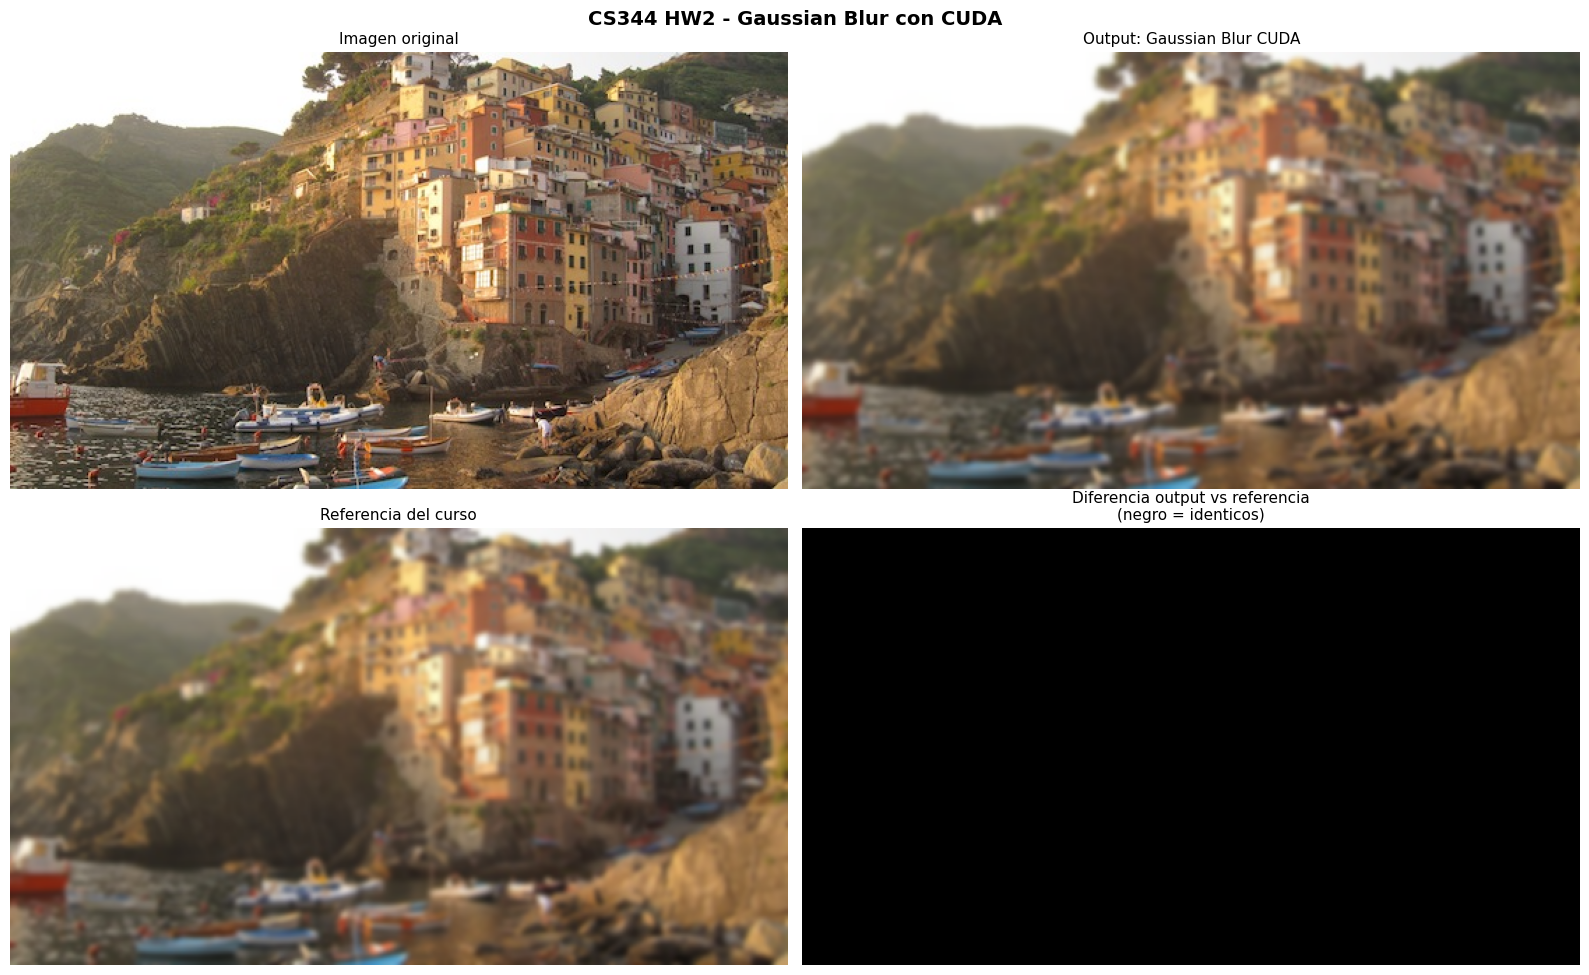

Resultado: PASS — Implementacion CUDA correcta.


In [ ]:
import cv2
import matplotlib.pyplot as plt
import glob

base = '/content/udacity-cs344-colab/src/HW2/'
todos = glob.glob(base + '*.png') + glob.glob(base + '*.jpg')

def buscar(patron):
    for f in todos:
        if patron.lower() in f.lower():
            return f
    return None

imagenes = [
    (buscar('cinque_terre_small.jpg'), 'Imagen original'),
    (buscar('output'),                 'Output: Gaussian Blur CUDA'),
    (buscar('reference'),              'Referencia del curso'),
    (buscar('difference'),             'Diferencia output vs referencia\n(negro = identicos)'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (path, title) in enumerate(imagenes):
    if path is not None:
        img = cv2.imread(path)
        if img is not None:
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            axes[i].text(0.5, 0.5, 'Error al leer', ha='center', va='center')
    else:
        axes[i].text(0.5, 0.5, 'No encontrado', ha='center', va='center')
    axes[i].set_title(title, fontsize=11)
    axes[i].axis('off')

plt.suptitle('CS344 HW2 - Gaussian Blur con CUDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Resultado: PASS — Implementacion CUDA correcta.')
